# lyricsLM: build a GPT from scratchCompanion notebook to the article.Runtime > Change runtime type > T4 GPU, then Runtime > Run all.Takes about 10 minutes.

In [1]:
import torch, torch.nn as nn, requests, re, time
from torch.nn import functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
if device == 'cpu':
    print('WARNING: no GPU. Go to Runtime > Change runtime type > T4 GPU.')
    print('On CPU this will take hours instead of minutes.')
import matplotlib.pyplot as plt
import json, os, shutil

device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PROJECT_DIR = '/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch'

In [4]:
import os

REPO_DIR = os.path.join(PROJECT_DIR, "repo")

if not os.path.exists(REPO_DIR):
    from google.colab import userdata
    token = userdata.get('GITHUB_TOKEN')
    !git clone -q https://{token}@github.com/parthabiswas1/lyricsLM.git "{REPO_DIR}"
    !git -C "{REPO_DIR}" config user.email "biswas_partha@hotmail.com"
    !git -C "{REPO_DIR}" config user.name "Partha Biswas"
    print("Cloned into Drive — this will now persist across sessions.")
else:
    print("Already exists in Drive:", REPO_DIR)

Already exists in Drive: /content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo


In [5]:
!find "{REPO_DIR}" -type f

/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/.git/description
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/.git/info/exclude
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/.git/hooks/fsmonitor-watchman.sample
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/.git/hooks/post-update.sample
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/.git/hooks/applypatch-msg.sample
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/.git/hooks/pre-applypatch.sample
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/.git/hooks/pre-receive.sample
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/.git/hooks/commit-msg.sample
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/.git/hooks/update.sample
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/.git/hooks/prepare-commit-msg.sample
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/r

## 1. Get the songbooks

In [6]:
BOOKS = {
    # ---- Indian poets, about 30% of the corpus ----
    'tagore_gitanjali':     7164,   # song offerings, the Nobel book
    'tagore_gardener':      6686,   # love poems
    'tagore_stray_birds':   6524,   # short aphorisms
    'tagore_fruit':         6522,   # Fruit-Gathering
    'tagore_crescent':      6520,   # The Crescent Moon
    'tagore_fugitive':      7971,   # The Fugitive
    'kabir_songs':          6519,   # Songs of Kabir, Tagore's translation
    'indian_anthology':    74751,   # Anthology of Modern Indian Poetry
    'naidu_threshold':       680,   # Sarojini Naidu

    # ---- Western poets, about 70% ----
    'dickinson':           12242,   # Poems, Three Series, Complete
    'poe':                 10031,   # Complete Poetical Works
    'frost_new_hampshire': 58611,   # 1923, contains our seed line
    'blake_songs':          1934,   # Songs of Innocence and of Experience
    'keats_1820':          23684,   # Poems Published in 1820
    'wordsworth':           8774,   # Poems in Two Volumes, Volume 1
    'wordsworth_tennyson': 14952,   # Selections
}
# Frost is public domain in the US. Outside the US he is in copyright
# until 2034, so delete that line if you are elsewhere.
# Do NOT add Shelley #4800 without reading the balance section: it is
# larger than everything above combined.

URL_PATTERNS = [
    'https://www.gutenberg.org/ebooks/{id}.txt.utf-8',
    'https://www.gutenberg.org/files/{id}/{id}-0.txt',
    'https://www.gutenberg.org/files/{id}/{id}.txt',
    'https://www.gutenberg.org/cache/epub/{id}/pg{id}.txt',
]
HEADERS = {'User-Agent': 'Mozilla/5.0 (compatible; lyricsLM-tutorial/1.0)'}

def fetch(book_id):
    for pattern in URL_PATTERNS:
        url = pattern.format(id=book_id)
        try:
            r = requests.get(url, headers=HEADERS, timeout=30)
            if r.status_code == 200 and len(r.text) > 5000:
                return r.text
        except Exception:
            pass
        time.sleep(1)
    raise RuntimeError(f'could not download book {book_id}')

raw = {}
for name, bid in BOOKS.items():
    raw[name] = fetch(bid)
    print(f'{name:24s} {len(raw[name]):>9,} chars')

tagore_gitanjali            97,888 chars
tagore_gardener             98,389 chars
tagore_stray_birds          51,545 chars
tagore_fruit                76,531 chars
tagore_crescent             67,836 chars
tagore_fugitive            131,550 chars
kabir_songs                119,004 chars
indian_anthology           147,642 chars
naidu_threshold             68,799 chars
dickinson                  206,658 chars
poe                        408,298 chars
frost_new_hampshire        136,813 chars
blake_songs                 52,343 chars
keats_1820                 277,698 chars
wordsworth                 111,878 chars
wordsworth_tennyson        276,289 chars


## 2. Clean it

In [7]:
def clean(text):
    # Cut the tail FIRST. Cutting the head first shifts every position,
    # which would make the end position point to the wrong place.
    end = re.search(r'\*\*\*\s*END OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*', text, re.S | re.I)
    if end:   text = text[:end.start()]
    start = re.search(r'\*\*\*\s*START OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*', text, re.S | re.I)
    if start: text = text[start.end():]

    text = text.replace('\r\n', '\n')
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    return text.strip()

cleaned = {n: clean(t) for n, t in raw.items()}
corpus = '\n\n'.join(cleaned.values())
print(f'{len(corpus):,} characters')
print()
print('--- your real numbers ---')
print('characters per step :', 128*64)
print('steps for one pass  :', round(len(corpus)/(128*64)))
print('20000 steps         :', round(20000/(len(corpus)/(128*64))), 'passes')
print()
print(corpus[:400])

print()
print('BALANCE  (no single book should be far above 25%)')
for name, txt in sorted(cleaned.items(), key=lambda kv: -len(kv[1])):
    share = len(txt)/len(corpus)*100
    flag = '   <-- too big' if share > 25 else ''
    print(f'  {name:24s} {share:5.1f}%{flag}')
indian = sum(len(t) for n,t in cleaned.items()
             if n.startswith(('tagore','kabir','indian','naidu')))
print(f'  Indian poets combined  {indian/len(corpus)*100:.0f}%')

1,863,214 characters

--- your real numbers ---
characters per step : 8192
steps for one pass  : 227
20000 steps         : 88 passes

Gitanjali

Song Offerings

by Rabindranath Tagore

A collection of prose translations made by the author from the original
Bengali

With an introduction by
W. B. YEATS

TO
WILLIAM ROTHENSTEIN

INTRODUCTION

A few days ago I said to a distinguished Bengali doctor of medicine, I
know no German, yet if a translation of a German poet had moved me, I
would go to the British Museum and find books in Eng

BALANCE  (no single book should be far above 25%)
  poe                       19.1%
  wordsworth_tennyson       12.9%
  keats_1820                12.8%
  dickinson                  9.3%
  indian_anthology           5.9%
  tagore_fugitive            5.8%
  frost_new_hampshire        5.7%
  kabir_songs                5.0%
  wordsworth                 4.5%
  tagore_gitanjali           4.0%
  tagore_gardener            3.9%
  tagore_fruit               2.9%
  naid

## 3. Tokenize

In [8]:
chars = sorted(set(corpus))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda nums: ''.join(itos[i] for i in nums)

print('vocab size:', vocab_size)
print(encode('miles to go'))
print(decode(encode('miles to go')))

vocab size: 85
[71, 67, 70, 63, 77, 1, 78, 73, 1, 65, 73]
miles to go


## 4. Batches

In [9]:
block_size = 128
batch_size = 64
n_embd = 192
n_head = 6
n_layer = 6
dropout = 0.2
learning_rate = 3e-4
max_steps = 20000

data = torch.tensor(encode(corpus), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print(xb.shape, yb.shape)

torch.Size([64, 128]) torch.Size([64, 128])


## 5. Attention

In [10]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k, q = self.key(x), self.query(x)
        w = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5
        w = w.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        w = F.softmax(w, dim=-1)
        w = self.dropout(w)
        return w @ self.value(x)

class MultiHead(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

## 6. Block and model

In [11]:
class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd), nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd), nn.Dropout(dropout))
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.sa  = MultiHead(n_head, n_embd // n_head)
        self.ff  = FeedForward()
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class LyricsLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block() for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_embedding(idx)
        pos = self.position_embedding(torch.arange(T, device=idx.device))
        x = self.blocks(tok + pos)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss

model = LyricsLM().to(device)
print(f'{sum(p.numel() for p in model.parameters()):,} parameters')

2,723,413 parameters


## 7. Train

In [ ]:
@torch.no_grad()
def estimate_loss(iters=50):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(iters)
        for k in range(iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
history = []

torch.save(model.state_dict(), 'checkpoint_0.pt')

for step in range(max_steps):
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if step % 500 == 0:
        l = estimate_loss()
        history.append((step, l['train'], l['val']))
        print(f"step {step:5d} | train {l['train']:.4f} | val {l['val']:.4f}")

    if step == max_steps // 2:
        torch.save(model.state_dict(), f'checkpoint_{max_steps // 2}.pt')

torch.save(model.state_dict(), 'checkpoint_final.pt')
print('done')

step     0 | train 4.1435 | val 4.1567
step   500 | train 2.2360 | val 2.3374
step  1000 | train 1.9359 | val 2.0573
step  1500 | train 1.7933 | val 1.9349
step  2000 | train 1.7136 | val 1.8507
step  2500 | train 1.6521 | val 1.8039
step  3000 | train 1.6106 | val 1.7514
step  3500 | train 1.5594 | val 1.7276
step  4000 | train 1.5340 | val 1.6933
step  4500 | train 1.5112 | val 1.6831
step  5000 | train 1.4974 | val 1.6614
step  5500 | train 1.4801 | val 1.6349
step  6000 | train 1.4631 | val 1.6303
step  6500 | train 1.4450 | val 1.6087
step  7000 | train 1.4294 | val 1.6037
step  7500 | train 1.4149 | val 1.5941
step  8000 | train 1.4089 | val 1.5850
step  8500 | train 1.3965 | val 1.5746
step  9000 | train 1.3834 | val 1.5780
step  9500 | train 1.3838 | val 1.5683
step 10000 | train 1.3680 | val 1.5612
step 10500 | train 1.3614 | val 1.5533
step 11000 | train 1.3511 | val 1.5437
step 11500 | train 1.3440 | val 1.5488
step 12000 | train 1.3438 | val 1.5536
step 12500 | train 1.3345

## 8. The loss curve

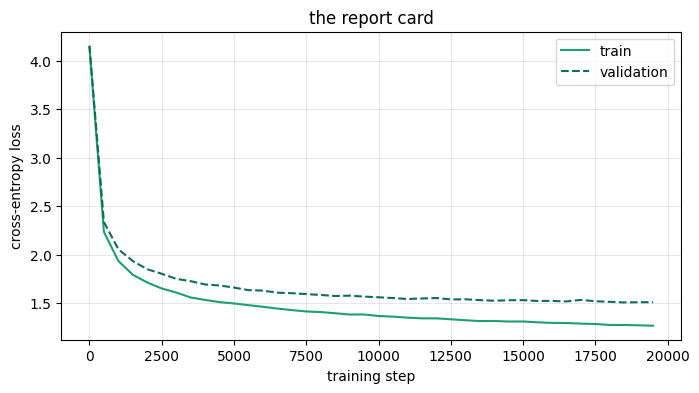

In [ ]:

steps = [h[0] for h in history]
plt.figure(figsize=(8,4))
plt.plot(steps, [h[1] for h in history], label='train', color='#1D9E75')
plt.plot(steps, [h[2] for h in history], label='validation', color='#0F6E56', linestyle='--')
plt.xlabel('training step'); plt.ylabel('cross-entropy loss')
plt.title('the report card'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 9. Generate

In [ ]:
@torch.no_grad()
def generate(model, seed, max_new_tokens=300, temperature=0.8):
    model.eval()
    idx = torch.tensor([encode(seed)], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        nxt = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, nxt), dim=1)
    return decode(idx[0].tolist())

print(generate(model, 'and miles to go before I sleep'))

and miles to go before I sleep,
 Like some plains of me,
 And I knew my childhood,
 Where the something dwell
 It brought alone and down my means that every
 days and blames, but the games is still, that the day
 Is the tender of lyrics of my life.

 Like this way-spark and switch of the glory hands,
 And the separate worlds hav


## 10. The reveal: three checkpoints, one seed

In [ ]:
seed = 'and miles to go before I sleep'   # <-- put your own line here

half_step = max_steps // 2
for name, path in [('baby', 'checkpoint_0.pt'),
                   ('halfway', f'checkpoint_{half_step}.pt'),
                   ('fully trained', 'checkpoint_final.pt')]:
    model.load_state_dict(torch.load(path))
    print(f'\n===== {name} =====')
    print(generate(model, seed, max_new_tokens=200))


===== baby =====
and miles to go before I sleepO-N,5&Eb?9CZzemN':gXr:6$NmDVKN)]HqbIX;eEx.3AcaF(Y`;-e+fCa,YC;_7Vz:+CM?Mq3
'e qqjLC+nVm79O-AD]y
wuvm(EZW0E_JaLn?lQc:zgIW;tTHgxop)J[$0B9;C-)
CyWpJW02 _?P3kPS'np'`;XuZn605Xv"'Ohg
!54;3?;7+"zZ4t9'2X?)IZvK

===== halfway =====
and miles to go before I sleep in the dead.

The wanderer one who has proved that you was you cannot what you have
make to me?

You me to my heart to some one in the diamond. One of your brain in His
nate bees the gates when you a

===== fully trained =====
and miles to go before I sleep:
 And the scarless till the stars will not care.

 We twenty but knocks suddenly by the eyes of the soul,
 And the companion's heart and turns to have to spread.
 Portion is this hopes--in the only g


## 11. Play with the creativity dial

In [ ]:
# Make sure we're generating from the fully trained model
model.load_state_dict(torch.load('checkpoint_final.pt'))

for t in [0.4, 0.8, 1.2]:
    print(f'\n--- temperature {t} ---')
    print(generate(model, 'the night is deep', max_new_tokens=150, temperature=t))


--- temperature 0.4 ---
the night is deep in the world of the sky,
 The morning sky, and the stars still the lover and said,
 "I have ended you with my heart and said,
 "Why do you not the li

--- temperature 0.8 ---
the night is deep--
 Quick not is it in the light
 That can strain? His father is a while,
 That once of the source is not with her love
 After they proud and asks,
 H

--- temperature 1.2 ---
the night is deep
 driven, when Saving was )
 Up-to who yet have it, and hasten with height is
 made associted.
 While one of the ground souls on conveyard a year's th


## 12. Reimplementing generation in pure NumPy

`nn.Linear`, `nn.Embedding`, `nn.LayerNorm`, `F.softmax` — none of it is magic. Training needs PyTorch, because training needs automatic differentiation, and nobody hand-computes gradients through six transformer blocks. But once training is done, generation is just arithmetic: multiply, add, softmax, sample. No calculus required.

The cells below reimplement the entire forward pass from section 6 — the same architecture, the same trained weights — using nothing but NumPy. If it produces the same numbers PyTorch does, that's proof every layer really is just the matrix math you've been reading about, with nothing hidden inside `nn.Module`.

In [ ]:
import numpy as np

# Pull the trained weights out of PyTorch's state_dict into plain NumPy arrays.
# From here on, nothing below touches torch at all.
W = {k: v.detach().cpu().numpy() for k, v in model.state_dict().items()}

def np_layer_norm(x, weight, bias, eps=1e-5):
    mean = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    return (x - mean) / np.sqrt(var + eps) * weight + bias

def np_linear(x, weight, bias=None):
    # nn.Linear stores weight as (out_features, in_features), hence the transpose
    out = x @ weight.T
    return out + bias if bias is not None else out

def np_softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)  # numerical stability
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

In [ ]:
def np_attention_head(x, b, h, T):
    p = f'blocks.{b}.sa.heads.{h}'
    k = np_linear(x, W[f'{p}.key.weight'])
    q = np_linear(x, W[f'{p}.query.weight'])
    v = np_linear(x, W[f'{p}.value.weight'])
    wei = q @ k.transpose(0, 2, 1) * (k.shape[-1] ** -0.5)
    mask = np.tril(np.ones((T, T)))
    wei = np.where(mask == 0, -1e10, wei)   # causal mask, same idea as masked_fill
    wei = np_softmax(wei, axis=-1)
    return wei @ v

def np_multi_head(x, b, T):
    outs = [np_attention_head(x, b, h, T) for h in range(n_head)]
    out = np.concatenate(outs, axis=-1)
    return np_linear(out, W[f'blocks.{b}.sa.proj.weight'], W[f'blocks.{b}.sa.proj.bias'])

def np_feed_forward(x, b):
    p = f'blocks.{b}.ff.net'
    x = np_linear(x, W[f'{p}.0.weight'], W[f'{p}.0.bias'])
    x = np.maximum(x, 0)  # ReLU
    return np_linear(x, W[f'{p}.2.weight'], W[f'{p}.2.bias'])

def np_block(x, b, T):
    ln1w, ln1b = W[f'blocks.{b}.ln1.weight'], W[f'blocks.{b}.ln1.bias']
    ln2w, ln2b = W[f'blocks.{b}.ln2.weight'], W[f'blocks.{b}.ln2.bias']
    x = x + np_multi_head(np_layer_norm(x, ln1w, ln1b), b, T)
    x = x + np_feed_forward(np_layer_norm(x, ln2w, ln2b), b)
    return x

def numpy_forward(idx):
    B, T = idx.shape
    tok = W['token_embedding.weight'][idx]
    pos = W['position_embedding.weight'][:T]
    x = tok + pos
    for i in range(n_layer):
        x = np_block(x, i, T)
    x = np_layer_norm(x, W['ln_f.weight'], W['ln_f.bias'])
    return np_linear(x, W['head.weight'], W['head.bias'])

### Proof: does it actually match?

Feed the same input through both the PyTorch model and this NumPy version, and compare the raw logits. If every layer above is a faithful translation, the two should agree to floating-point precision.

In [ ]:
idx_check = torch.tensor([encode('and miles to go')], dtype=torch.long).to(device)

with torch.no_grad():
    torch_logits, _ = model(idx_check)

np_logits = numpy_forward(idx_check.cpu().numpy())

diff = np.max(np.abs(torch_logits.cpu().numpy() - np_logits))
print(f'max abs difference: {diff:.2e}')
print('MATCH — the NumPy version is the same function, just without a framework.' if diff < 1e-3 else 'MISMATCH — something above doesn\'t line up.')

max abs difference: 5.72e-06
MATCH — the NumPy version is the same function, just without a framework.


### Generating with it

The sampling loop is the same idea as section 9's `generate()` — feed in tokens, take the last position's logits, apply temperature, softmax, sample, repeat — just built on `numpy_forward` instead of `model(...)`.

In [ ]:
def generate_numpy(seed, max_new_tokens=200, temperature=0.8):
    idx = np.array([encode(seed)], dtype=np.int64)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]
        logits = numpy_forward(idx_cond)
        logits = logits[:, -1, :] / temperature
        probs = np_softmax(logits, axis=-1)[0]
        nxt = np.random.choice(len(probs), p=probs)
        idx = np.concatenate([idx, np.array([[nxt]])], axis=1)
    return decode(idx[0].tolist())

print(generate_numpy('and miles to go before I sleep'))

and miles to go before I sleep"
 His infinite wild not who has not mercy with companion.
 The shade made struck behind me, with what he left me exist
 in his heart.
 The winds should I can not build the human height of the Lord is


## 13. Export weights for deployment

The live demo runs the exact NumPy forward pass above on a small server — no PyTorch installed there at all, since inference alone doesn't need it. This cell exports the trained weights as a plain NumPy `.npz` file (loadable with zero PyTorch dependency) plus `config.json` with the vocabulary and architecture settings the server needs.

In [ ]:
# Make sure we're exporting the fully trained model
model.load_state_dict(torch.load('checkpoint_final.pt'))

npz_dict = {k: v.detach().cpu().numpy().astype(np.float32) for k, v in model.state_dict().items()}

MODEL_DIR = os.path.join(REPO_DIR, 'backend', 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

npz_path = os.path.join(MODEL_DIR, 'trained_weights.npz')
np.savez(npz_path, **npz_dict)
print(f'Saved {len(npz_dict)} tensors -> {npz_path}  ({os.path.getsize(npz_path)/1e6:.1f} MB)')

config = {
    'vocab_size': vocab_size,
    'n_embd': n_embd,
    'n_head': n_head,
    'n_layer': n_layer,
    'block_size': block_size,
    'stoi': stoi,
    'itos': {str(k): v for k, v in itos.items()},
}
config_path = os.path.join(MODEL_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f)
print('config.json written ->', config_path)

Saved 210 tensors -> /content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/backend/model/trained_weights.npz  (13.3 MB)
config.json written -> /content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/backend/model/config.json


### Bring in the updated backend code

The NumPy backend's `index.py` and `requirements.txt` live outside this notebook (delivered separately). Upload them once into `PROJECT_DIR/backend/api/index.py` and `PROJECT_DIR/backend/requirements.txt` in Drive, then this cell copies the current versions into the repo every time you run it — so Section 14 always pushes the latest backend code alongside the latest weights.

In [ ]:
# Expects you've uploaded the current backend code into Drive at:
#   PROJECT_DIR/backend/api/index.py
#   PROJECT_DIR/backend/requirements.txt
BACKEND_SRC = os.path.join(PROJECT_DIR, 'backend')
BACKEND_DEST = os.path.join(REPO_DIR, 'backend')

os.makedirs(os.path.join(BACKEND_DEST, 'api'), exist_ok=True)
shutil.copy(os.path.join(BACKEND_SRC, 'api', 'index.py'), os.path.join(BACKEND_DEST, 'api', 'index.py'))
shutil.copy(os.path.join(BACKEND_SRC, 'requirements.txt'), os.path.join(BACKEND_DEST, 'requirements.txt'))

print('Backend code copied into repo:')
!find "{BACKEND_DEST}" -type f -not -path "*/model/*"


Backend code copied into repo:
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/backend/api/index.py
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/backend/requirements.txt
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/backend/vercel.json


### Bring in the updated frontend code

Same pattern as the backend: `demo.html`, `index.html`, and `js/app.js` live in Drive (edited directly, or replaced when a new version is delivered). This cell copies the current versions into the repo every time you run it, so a push always carries whatever's currently in Drive — no separate manual step to remember.

In [ ]:
FRONTEND_SRC = os.path.join(PROJECT_DIR, 'frontend')
FRONTEND_DEST = os.path.join(REPO_DIR, 'frontend')

for name in ['index.html', 'demo.html']:
    shutil.copy(os.path.join(FRONTEND_SRC, name), os.path.join(FRONTEND_DEST, name))
shutil.copy(os.path.join(FRONTEND_SRC, 'js', 'app.js'), os.path.join(FRONTEND_DEST, 'js', 'app.js'))

print('Frontend code copied into repo:')
!find "{FRONTEND_DEST}" -type f -not -path "*/weights/*"


Frontend code copied into repo:
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/frontend/README.md
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/frontend/css/styles.css
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/frontend/demo.html
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/frontend/index.html
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/repo/frontend/js/app.js


## 14. Publish to GitHub

`REPO_DIR` (set up back in section 1) points at a permanent clone living inside Drive, so it survives Colab runtime restarts. This cell copies the notebook itself plus the exported weights into that repo, then commits and pushes — Vercel and Cloudflare Pages both auto-deploy from this repo, so a push here is what actually updates the live site.

In [ ]:
# Copy the current notebook into the repo (adjust the source filename if yours differs)
!cp "{PROJECT_DIR}/lyricsLM.ipynb" "{REPO_DIR}/notebook/lyricsLM.ipynb"

!cd "{REPO_DIR}" && git add -A && git commit -m "update notebook and weights" && git push